# ***Training Models***

## ***Linear Regression***

*Linear model make prediction by simply computing weighted sum of the input feature also add a constant called bias*

$$\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_{n} x_n$$
- $\hat{y}$ is output feature
- $\theta_0$ is bias term
- $\theta_i$ is the weight/model parameter of $i^{th}$ input feature 
- $x_i$ is $i^{th}$ feature value

*In vectorized form this is ~*

$$\hat{y} = h_{\theta}(X) = \theta X$$
- $h_{\theta}$ is the hypothesis function using model parameter $\theta$
- $\theta$ is the model parameter vector containing bias($\theta_0$) & $\theta_1$ to $\theta_n$
- $X$ is the instance's feature vector, containing $x_0$ to $x_n$ where $x_0$ is always 1
- $\theta .X$ is $\theta_0 x_0+ \theta_1 x_1 + \theta_2 x_2 + \cdots + \theta_{n} x_n$

**Training the linear model neans seting the parameters such the model best fit the training set**

**To find how well or badly the model fit the data we need some performance measure, in regression model most common is `RMSE`, So mwe need to find the value of $\theta$ that minimize the value of `RMSE` ~ In practice use `MSE` as both give same result & it's computationally simpler**

*`MSE` of $h_{\theta}$ on a training set(X) is calculated using the equation ~*

$$MSE(X, y, h_{\theta}) = \frac{1}{m} \sum_{i = 0}^{n}(\theta^T X^{(i)} - y^{(i)})^2$$

### ***The Normal Equation***

*The closed form equation to get the valule of $\theta$ that minimizes the value of `MSE` is ~*

$$\hat{y} = (X^TX)^{-1}X^Ty$$

In [4]:
import numpy as np 

rng = np.random.default_rng(seed = 42)
m = 200 # instances 
x = 2 * rng.random((m,1)) # column vector
y = 4 + 3 * x + rng.standard_normal((m,1)) # column vector

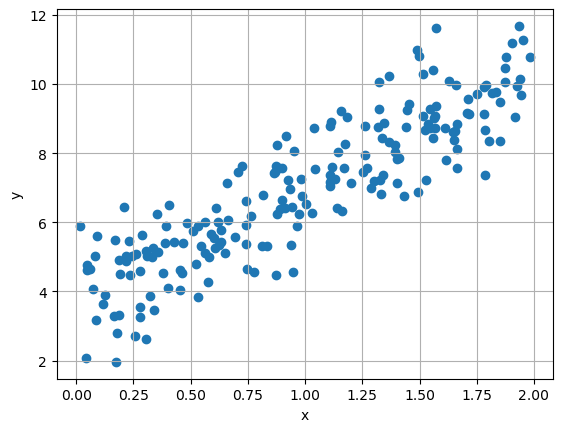

In [8]:
import matplotlib.pyplot as plt

plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y') 
plt.grid()
plt.show()

In [9]:
from sklearn.preprocessing import add_dummy_feature

x_b = add_dummy_feature(x) # adds a column of 1s to the left of x
theta_best = np.linalg.inv(x_b.T @ x_b)@ x_b.T @ y
print(theta_best)

[[3.69084138]
 [3.32960458]]


***Function used to generate data is ~*** $y = 3x_1 + 4 + \text{noise}$

***So we expected $\theta_0 = 4, \theta_1 = 3$ instead we got $\theta_1 = 3.6908, \theta_1 = 3.3296$ for the noise, the smaller & noiser the data is the harder it gets to get the original parapeter***

In [10]:
x_new = np.array([[0],[2]])
x_new_b = add_dummy_feature(x_new) # add x_0 = 1 to each instance
y_predict = x_new_b @ theta_best
print(y_predict)

[[ 3.69084138]
 [10.35005055]]


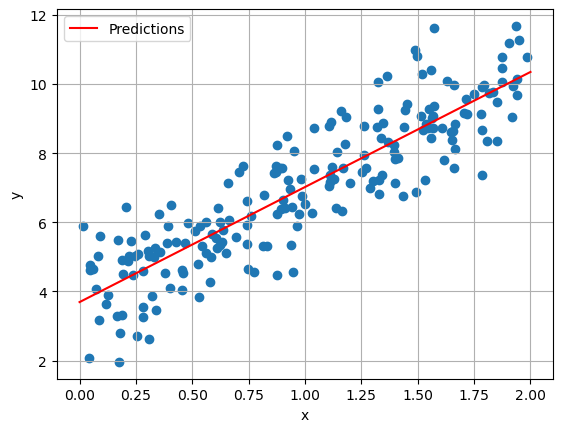

In [12]:
plt.plot(x_new, y_predict, 'r-', label = 'Predictions')
plt.scatter(x, y)
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.legend()
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

lin = LinearRegression()
lin.fit(x, y)
lin.intercept_, lin.coef_
lin.predict(x_new)

array([[ 3.69084138],
       [10.35005055]])

***LinearRegression class is based on `scipy.linalg.lstsq()` function***

*This function use*

$$\hat{\theta} = X^+y \text{ , where $X^+$ is pseudoinverse of } X$$

***Can use `np.linalg.pinv()` to compute the p. inverse***

In [17]:
theta_best_svd, residuals, rank, s =  np.linalg.lstsq(x_b, y, rcond=1e-6)
theta_best_svd, residuals, rank, s

(array([[3.69084138],
        [3.32960458]]),
 array([199.16171014]),
 2,
 array([20.71206939,  5.43847   ]))

In [18]:
np.linalg.pinv(x_b) @ y

array([[3.69084138],
       [3.32960458]])

***This pseudoinverse is computed using a standard `matrix factorization` technique called `Singular Value Decomposition`***

***The `Normal Equation` may not work if ~***
- $X^TX$ is not invertable
- If `m < n`  
- Some feature are redundant

### ***Computational Complexity***

***`Normal Equation` compute inverse of $X^TX$ a `(n+1) x (n+1)` matrix `{n is no of features}`, The computational cost is $O(n^{2.4}) \text{ to } O(n^{3})$ means if double the feature no the computation cost goes from $2^{2.4} = 5.3 \text{ to } 2^{3} = 8$***

***In `SVD` the complexity is $O(n^2)$, if double the feature no the complexity will multiply by 4 times***

***After training the prediction is very fast, the computational complexity is linear to the no of instances I want predict on  & the feature no***

## ***Gradient Descent***

*Generic optimizing algorithm*

***The `MSE` cost function for linear regression model is a `convex function` means if I pick any 2 point on the curve & join them the line will never be below the curve, this implies there is no local minima only global minima***

***It also a continuous func with a slope that never changes abruptly means `smooth curve`***

***The step the gradient take is determined by the learning rate***

***The more parameters the model has the more dimension the parameter space so harder the search is***

`While doing gradaient D. ensure all features are in same scale`

### ***Batch Gradient Descent***

***Most model have more that 1 parameter so to implement gradient descent, so to implement GD we need to compute the gradient of cost fucntion with regard to each parameter $\theta_j$ this is called `partial derivative`***

*Partial derivative of the MSE with regard of MSE ~*

$$\frac{\partial}{\partial \theta_j} MSE(\theta) = \frac{2}{m} \sum_{i=1}{m} (\theta^T X^{(i)} - y^{(i)})x_j^{(i)}$$

***All the partial derivatives of the cost func(`one for each model parameter`) are calculated in a vector in one go `gradient vector` $\nabla_{\theta}MSE(\theta)$***

$$\nabla_{\theta}MSE(\theta) = 
(\begin{array}{c} \frac{\partial}{\partial \theta_0} MSE(\theta) \\ \frac{\partial}{\partial \theta_1} MSE(\theta) \\ \vdots \\ \frac{\partial}{\partial \theta_n} MSE(\theta) \end{array}) = \frac{2}{m} X^T(X \theta - y)$$

***When the gradient vector points uphill , just go in opposite downhill ~*** 
- Substract $\nabla_{\theta}MSE(\theta)$ from $\theta$
- Multiply the `gradient vector` with `learning rate`($\eta$) to determine the size of the downhill step

$$\theta^{(next step)} = \theta - \eta \nabla_{\theta} MSE(\theta)$$

In [ ]:
eta = 0.1 # learning rate 
n_epoch = 1000 # number of iterations
m = len(x_b) # number of instances

theta = np.random.randn(2,1) # random initialization


***How to set the number of epochs ~ when the gradient vector become tiny (when it's norm become smaller than a tiny number $\epsilon$ `(tolerance)`), this happen when the gradient has reached the minima***

### ***Stochastic Gradient Descent***

- *In gradient descent it use the whole training set in every step to compute the gradient*
- *In SGD we use any random one instance for calculating gradient* 
- *In SGD the gradient won't descent smoothly to the minima, the cost function will bounce up & down*
- *Eventually it will end up near minimum but won't be optimal*
- *As the cost func is very irregular it may help the algo jump local minima, but bad thing is the gradient can never settle at minimum*
- *The func that determine the learning rate in each iteration is called learning schedule*
- *If the LR is reduced too quickly the I may stuck in local minima or stop halfway, if reduced slowly may jump around the minimum & stop in a suboptimal solution*

In [ ]:
n_epochs = 1000
lr1, lr2 = 4, 40
m = len(x_b)

def learning_schedule(t):
    return lr1 /(t + lr2)

rng = np.random.default_rng(seed=42)
theta = rng.standard_normal((2,1)) # random initialization of parameter

for epoch in range(n_epochs):
    pass